<a href="https://colab.research.google.com/github/Sansebastian318/Mecanica/blob/main/primera_idea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


RMSE (retornos): 0.022865
Precio estimado al final del período: $200,959.55


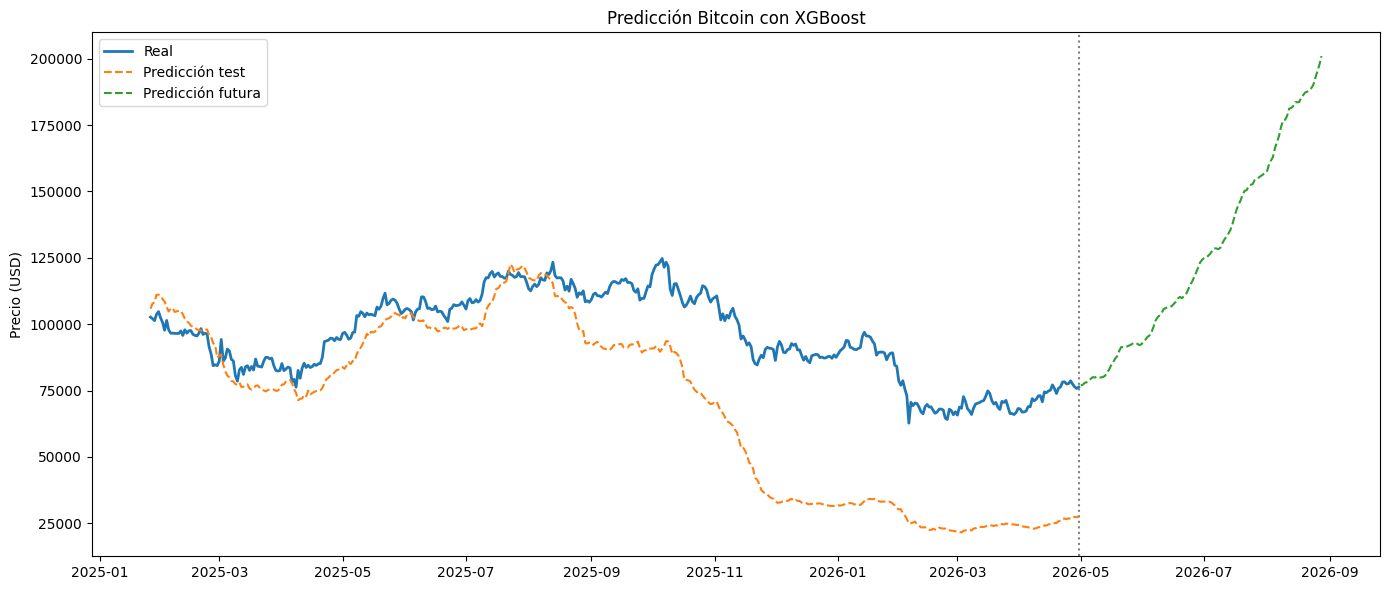

In [33]:
# 1. LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# 2. DESCARGAR DATOS
btc = yf.download("BTC-USD", start="2020-01-01", end="2026-05-01", auto_adjust=True)

if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

data = btc[['Close', 'Volume']].copy()

# 3. CREAR VARIABLE OBJETIVO (RETORNO)
data['Return'] = data['Close'].pct_change()

# CONFIGURACIÓN
N_LAGS = 15
ROLLING_WIN = 15

# 4. CREAR FEATURES BASADAS EN RETORNOS
for lag in range(1, N_LAGS + 1):
    data[f'lag_{lag}'] = data['Return'].shift(lag)

data['rolling_mean'] = data['Return'].rolling(window=ROLLING_WIN).mean()
data['rolling_std']  = data['Return'].rolling(window=ROLLING_WIN).std()

data['volume_mean'] = data['Volume'].rolling(window=ROLLING_WIN).mean()
data['volume_std']  = data['Volume'].rolling(window=ROLLING_WIN).std()

# LIMPIAR NaN
data.dropna(inplace=True)

# 5. DEFINIR X e y
X = data.drop(['Close', 'Return'], axis=1)
y = data['Return']

# 6. DIVIDIR DATOS
train_size = int(len(data) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 7. MODELO
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.14,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=1
)

model.fit(X_train, y_train)

# 8. PREDICCIONES EN TEST
pred_returns = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_returns))
print(f"RMSE (retornos): {rmse:.6f}")

# Convertir retornos a precios reales para comparar
test_prices_real = data['Close'].iloc[train_size:]

pred_prices = []
last_price = data['Close'].iloc[train_size - 1]

for r in pred_returns:
    last_price = last_price * (1 + r)
    pred_prices.append(last_price)

# 9. FUNCIÓN PARA FUTURO
def build_features(return_series, volume_series):
    lags = [return_series.iloc[-i] for i in range(1, N_LAGS + 1)]

    rolling_mean = return_series.iloc[-ROLLING_WIN:].mean()
    rolling_std  = return_series.iloc[-ROLLING_WIN:].std()

    volume_mean = volume_series.iloc[-ROLLING_WIN:].mean()
    volume_std  = volume_series.iloc[-ROLLING_WIN:].std()

    return pd.DataFrame([[*lags,
                          volume_series.iloc[-1],
                          rolling_mean,
                          rolling_std,
                          volume_mean,
                          volume_std]],
                        columns=X.columns)

# 10. PREDICCIÓN FUTURA
future_days = 120

history_returns = data['Return'].copy()
history_volume  = data['Volume'].copy()

future_predictions = []

last_price = data['Close'].iloc[-1]

for _ in range(future_days):
    X_future = build_features(history_returns, history_volume)

    pred_return = float(model.predict(X_future)[0])
    pred_return = np.clip(pred_return, -0.03, 0.03)

    last_price = last_price * (1 + pred_return)

    future_predictions.append(last_price)

    next_date = history_returns.index[-1] + pd.Timedelta(days=1)

    history_returns.loc[next_date] = pred_return
    history_volume.loc[next_date] = history_volume.iloc[-ROLLING_WIN:].mean()

print(f"Precio estimado al final del período: ${future_predictions[-1]:,.2f}")

# 11. GRAFICAR
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days,
    freq='D'
)

plt.figure(figsize=(14,6))

plt.plot(test_prices_real.index, test_prices_real.values,
         label="Real", linewidth=2)

plt.plot(test_prices_real.index, pred_prices,
         label="Predicción test", linestyle="--")

plt.plot(future_dates, future_predictions,
         label="Predicción futura", linestyle="--")

plt.axvline(x=data.index[-1], color='gray', linestyle=':')

plt.legend()
plt.title("Predicción Bitcoin con XGBoost")
plt.ylabel("Precio (USD)")
plt.tight_layout()
plt.show()